In [1]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import shutil
import time
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xgboost as xgb
from requests.adapters import HTTPAdapter
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from urllib3.util.retry import Retry

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

print("XGBoost version:", xgb.__version__)


XGBoost version: 3.2.0


In [ ]:
# %%
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MANUAL_DATA_DIRS: list[str] = []


# Script se tai PSV truc tiep tu PhysioNet ve /kaggle/working roi moi train.
DOWNLOAD_FROM_PHYSIONET = True
DOWNLOAD_SET_A = True
DOWNLOAD_SET_B = True

# Full official:
# A: p000001 -> p020643
# B: p100001 -> p120000
# Neu muon test nhanh, giam SET_A_END / SET_B_END truoc.
SET_A_START, SET_A_END = 1, 20643
SET_B_START, SET_B_END = 1, 20000

OUT_DIR_A = "/kaggle/working/Data-Set-A" if Path("/kaggle").exists() else "data/Data-Set-A"
OUT_DIR_B = "/kaggle/working/Data-Set-B" if Path("/kaggle").exists() else "data/Data-Set-B"

BASE_URL_A = "https://physionet.org/files/challenge-2019/1.0.0/training/training_setA"
BASE_URL_B = "https://physionet.org/files/challenge-2019/1.0.0/training/training_setB"
FNAME_TMPL_A = "p{idx:06d}.psv"
FNAME_TMPL_B = "p1{idx:05d}.psv"

MAX_DOWNLOAD_WORKERS = 8
DOWNLOAD_TIMEOUT = 30
DOWNLOAD_MAX_RETRIES = 5
DOWNLOAD_BACKOFF_FACTOR = 1.0
DOWNLOAD_THROTTLE_SECONDS = 0.0
SKIP_IF_EXISTS = True

# De None neu muon train full data.
# Neu muon test nhanh tren Kaggle truoc, dat 1000 hoac 3000.
MAX_PATIENTS: int | None = None

# De None neu muon giu toan bo negative patients.
# Neu bi thieu RAM, co the dat 0.5 de lay 50% non-sepsis patients.
NEGATIVE_PATIENT_KEEP_RATE = 1.0

# Khong phai tham so cua Kaggle.
# Day la so gio ICU lich su dua vao XGBoost:
#   6 = gio hien tai + 5 gio truoc.
# Phai giong Spark inference trong `spark/app/spark_stream.py`, hien dang hardcode:
#   current row + range(1, 6) previous rows.
# Neu doi thanh 1/12/24 thi phai sua Spark inference theo, neu khong model se sai shape.
WINDOW_SIZE = 6
OUTPUT_DIR = Path("/kaggle/working/sepsis_model_export") if Path("/kaggle").exists() else Path("sepsis_model_export")
OUTPUT_ZIP = OUTPUT_DIR.with_suffix(".zip")

# Ten nay de project Spark biet day la model dung cho pipeline hien tai.
MODEL_NAME = "sepsis_xgboost_kaggle"

FEATURE_ORDER = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2", "BaseExcess", "HCO3",
    "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN", "Alkalinephos", "Calcium", "Chloride",
    "Creatinine", "Bilirubin_direct", "Glucose", "Lactate", "Magnesium", "Phosphate",
    "Potassium", "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT", "WBC", "Fibrinogen",
    "Platelets", "Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS",
]

# Cac cot duong va lech phan phoi manh, nen log-transform truoc khi standardize.
# Phai giong voi Spark inference neu khong model se du doan sai.
LOG_INDICES = {14, 15, 16, 19, 20, 22, 25, 26, 27, 30, 31, 32}

print("Output dir:", OUTPUT_DIR)
print("Model input features:", len(FEATURE_ORDER) * 3 * WINDOW_SIZE)

Output dir: /kaggle/working/sepsis_model_export
Model input features: 720


In [ ]:

def build_download_session() -> requests.Session:
    session = requests.Session()
    retry = Retry(
        total=DOWNLOAD_MAX_RETRIES,
        backoff_factor=DOWNLOAD_BACKOFF_FACTOR,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET", "HEAD"]),
    )
    session.mount("https://", HTTPAdapter(max_retries=retry))
    session.mount("http://", HTTPAdapter(max_retries=retry))
    session.headers.update({"User-Agent": "physionet-sepsis-kaggle-trainer/1.0"})
    return session


def download_one(session: requests.Session, url: str, out_path: Path) -> str:
    if SKIP_IF_EXISTS and out_path.exists() and out_path.stat().st_size > 0:
        return "skipped"

    tmp_path = out_path.with_suffix(".part")
    try:
        with session.get(url, stream=True, timeout=DOWNLOAD_TIMEOUT) as response:
            if response.status_code == 200:
                with tmp_path.open("wb") as handle:
                    for chunk in response.iter_content(chunk_size=16_384):
                        if chunk:
                            handle.write(chunk)
                os.replace(tmp_path, out_path)
                if DOWNLOAD_THROTTLE_SECONDS:
                    time.sleep(DOWNLOAD_THROTTLE_SECONDS)
                return "ok"
            if response.status_code == 404:
                return "not_found"
            return f"http_{response.status_code}"
    except Exception as exc:
        return f"error:{exc}"
    finally:
        if tmp_path.exists():
            try:
                tmp_path.unlink()
            except OSError:
                pass


def bulk_download(base_url: str, fname_tmpl: str, start: int, end: int, out_dir: str, label: str) -> None:
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    tasks = [
        (f"{base_url}/{fname_tmpl.format(idx=i)}", out_path / fname_tmpl.format(idx=i))
        for i in range(start, end + 1)
    ]

    session = build_download_session()
    results: dict[str, str] = {}

    with ThreadPoolExecutor(max_workers=MAX_DOWNLOAD_WORKERS) as executor:
        futures = {executor.submit(download_one, session, url, path): (url, path) for url, path in tasks}
        with tqdm(total=len(tasks), desc=label, unit="file") as progress:
            for future in as_completed(futures):
                _, path = futures[future]
                try:
                    status = future.result()
                except Exception as exc:
                    status = f"exception:{exc}"
                results[path.name] = status
                progress.update(1)

    ok = sum(1 for status in results.values() if status == "ok")
    skipped = sum(1 for status in results.values() if status == "skipped")
    not_found = sum(1 for status in results.values() if status == "not_found")
    errors = [(name, status) for name, status in results.items() if status not in {"ok", "skipped", "not_found"}]

    print(f"\n{label}")
    print(f"  ok       : {ok:,}")
    print(f"  skipped  : {skipped:,}")
    print(f"  not_found: {not_found:,}")
    print(f"  errors   : {len(errors):,}")
    if errors:
        print("  first errors:", errors[:10])


if DOWNLOAD_FROM_PHYSIONET:
    if DOWNLOAD_SET_A:
        bulk_download(BASE_URL_A, FNAME_TMPL_A, SET_A_START, SET_A_END, OUT_DIR_A, "Training Set A")
    if DOWNLOAD_SET_B:
        bulk_download(BASE_URL_B, FNAME_TMPL_B, SET_B_START, SET_B_END, OUT_DIR_B, "Training Set B")
else:
    print("Skipping download. The script will search existing PSV files.")


# 3. Tim file PSV sau khi tai xong


def find_psv_files() -> list[Path]:
    if MANUAL_DATA_DIRS:
        files: list[Path] = []
        for raw_dir in MANUAL_DATA_DIRS:
            files.extend(sorted(Path(raw_dir).glob("*.psv")))
        return sorted(files)

    candidate_roots = [
        Path(OUT_DIR_A),
        Path(OUT_DIR_B),
        Path("/kaggle/input"),
        Path("/kaggle/working/data"),
        Path("/kaggle/working"),
        Path("data/Data-Set-A"),
        Path("data/Data-Set-B"),
        Path("data"),
    ]

    files = []
    seen = set()
    for root in candidate_roots:
        if not root.exists():
            continue
        for path in root.rglob("*.psv"):
            if path.name in seen:
                continue
            seen.add(path.name)
            files.append(path)

    return sorted(files)


all_files = find_psv_files()
print("Total PSV files found:", len(all_files))
print("First 5 files:", [str(p) for p in all_files[:5]])

if len(all_files) == 0:
    raise FileNotFoundError(
        "Khong tim thay file .psv. Hay bat DOWNLOAD_FROM_PHYSIONET=True hoac sua MANUAL_DATA_DIRS."
    )

Training Set A:   0%|          | 0/20643 [00:00<?, ?file/s]


Training Set A
  ok       : 20,336
  skipped  : 0
  not_found: 307
  errors   : 0


Training Set B:   0%|          | 0/20000 [00:00<?, ?file/s]


Training Set B
  ok       : 20,000
  skipped  : 0
  not_found: 0
  errors   : 0
Total PSV files found: 40336
First 5 files: ['/kaggle/working/Data-Set-A/p000001.psv', '/kaggle/working/Data-Set-A/p000002.psv', '/kaggle/working/Data-Set-A/p000003.psv', '/kaggle/working/Data-Set-A/p000004.psv', '/kaggle/working/Data-Set-A/p000005.psv']


In [ ]:
# 4. Doc label theo patient va chia train/val/test

# Split theo patient giup tranh leakage. Neu split tung row, cung mot benh nhan co the nam ca train/test va metric se ao.

def patient_has_sepsis(path: Path) -> int:
    try:
        labels = pd.read_csv(path, sep="|", usecols=["SepsisLabel"])["SepsisLabel"].values
        return int(np.nanmax(labels) > 0)
    except Exception:
        return 0


patient_table = pd.DataFrame({
    "path": all_files,
    "patient_id": [p.stem for p in all_files],
})
patient_table["has_sepsis"] = [patient_has_sepsis(p) for p in patient_table["path"]]

print(patient_table["has_sepsis"].value_counts().rename({0: "non_sepsis", 1: "sepsis"}))
print("Sepsis patient rate:", patient_table["has_sepsis"].mean())

if NEGATIVE_PATIENT_KEEP_RATE < 1.0:
    pos = patient_table[patient_table["has_sepsis"] == 1]
    neg = patient_table[patient_table["has_sepsis"] == 0].sample(
        frac=NEGATIVE_PATIENT_KEEP_RATE,
        random_state=SEED,
    )
    patient_table = pd.concat([pos, neg]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print("After negative downsample:", patient_table["has_sepsis"].value_counts())

if MAX_PATIENTS is not None and len(patient_table) > MAX_PATIENTS:
    # Lay sample stratified theo has_sepsis.
    patient_table = (
        patient_table
        .groupby("has_sepsis", group_keys=False)
        .apply(lambda df: df.sample(
            n=max(1, int(MAX_PATIENTS * len(df) / len(patient_table))),
            random_state=SEED,
        ))
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )
    patient_table = patient_table.iloc[:MAX_PATIENTS].copy()
    print("After MAX_PATIENTS:", len(patient_table), patient_table["has_sepsis"].value_counts())

train_df, temp_df = train_test_split(
    patient_table,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_table["has_sepsis"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["has_sepsis"],
)

print("Train patients:", len(train_df), train_df["has_sepsis"].value_counts().to_dict())
print("Val patients:", len(val_df), val_df["has_sepsis"].value_counts().to_dict())
print("Test patients:", len(test_df), test_df["has_sepsis"].value_counts().to_dict())



# 5. Tinh scaler tren train only

# Cac buoc:
# - Mean/std tren raw feature.
# - Mean/std tren log(feature) cho cac cot lab lech phan phoi.
# - NaN mean duoc fill bang 0, std bang 1 de tranh loi.

def read_features_and_label(path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(path, sep="|")
    missing = [c for c in FEATURE_ORDER + ["SepsisLabel"] if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")
    x_raw = df[FEATURE_ORDER].astype(float).values
    y_raw = df["SepsisLabel"].astype(float).values
    valid = y_raw >= 0
    return x_raw[valid], y_raw[valid].astype(int)


def compute_scaler(paths: list[Path]) -> dict[str, list[float]]:
    chunks = []
    for i, path in enumerate(paths, start=1):
        x_raw, y_raw = read_features_and_label(path)
        if len(y_raw):
            chunks.append(x_raw)
        if i % 5000 == 0:
            print(f"Scaler read {i}/{len(paths)} patients")

    all_x = np.vstack(chunks).astype(np.float64)

    varmeans = np.nanmean(all_x, axis=0)
    varstds = np.nanstd(all_x, axis=0)

    log_x = np.copy(all_x)
    for i in LOG_INDICES:
        log_x[:, i] = np.log(np.clip(log_x[:, i], 1e-6, None))
    varlogmeans = np.nanmean(log_x, axis=0)
    varlogstds = np.nanstd(log_x, axis=0)

    varmeans = np.nan_to_num(varmeans, nan=0.0, posinf=0.0, neginf=0.0)
    varstds = np.nan_to_num(varstds, nan=1.0, posinf=1.0, neginf=1.0)
    varstds[varstds == 0] = 1.0

    varlogmeans = np.nan_to_num(varlogmeans, nan=0.0, posinf=0.0, neginf=0.0)
    varlogstds = np.nan_to_num(varlogstds, nan=1.0, posinf=1.0, neginf=1.0)
    varlogstds[varlogstds == 0] = 1.0

    return {
        "varmeans": varmeans.tolist(),
        "varstds": varstds.tolist(),
        "varlogmeans": varlogmeans.tolist(),
        "varlogstds": varlogstds.tolist(),
    }


t0 = time.time()
scaler = compute_scaler(train_df["path"].tolist())
print("Scaler computed in seconds:", round(time.time() - t0, 2))



has_sepsis
non_sepsis    37404
sepsis         2932
Name: count, dtype: int64
Sepsis patient rate: 0.07268940896469656
Train patients: 28235 {0: 26183, 1: 2052}
Val patients: 6050 {0: 5610, 1: 440}
Test patients: 6051 {0: 5611, 1: 440}
Scaler read 5000/28235 patients
Scaler read 10000/28235 patients
Scaler read 15000/28235 patients
Scaler read 20000/28235 patients
Scaler read 25000/28235 patients
Scaler computed in seconds: 82.38


In [ ]:

def preprocess_patient(x_raw: np.ndarray, scaler_params: dict[str, list[float]]) -> np.ndarray:
    data = np.array(x_raw, dtype=np.float32, copy=True)
    t_count, feature_count = data.shape
    if feature_count != len(FEATURE_ORDER):
        raise ValueError(f"Expected {len(FEATURE_ORDER)} features, got {feature_count}")

    varmeans = np.asarray(scaler_params["varmeans"], dtype=np.float32)
    varstds = np.asarray(scaler_params["varstds"], dtype=np.float32)
    varlogmeans = np.asarray(scaler_params["varlogmeans"], dtype=np.float32)
    varlogstds = np.asarray(scaler_params["varlogstds"], dtype=np.float32)

    # Missing mask: 1 = observed, 0 = missing.
    mask = (~np.isnan(data)).astype(np.float32)

    # Giong Spark inference:
    # 1. Fill NaN bang mean tam thoi.
    # 2. Forward-fill theo feature neu row hien tai missing.
    nan_rows, nan_cols = np.where(np.isnan(data))
    if len(nan_rows):
        data[nan_rows, nan_cols] = varmeans[nan_cols]

    forward = np.copy(data[0, :])
    for t in range(t_count):
        observed_cols = mask[t, :] == 1
        forward[observed_cols] = data[t, observed_cols]
        data[t, ~observed_cols] = forward[~observed_cols]

    # Delta tren raw-filled data.
    delta = np.zeros_like(data, dtype=np.float32)
    if t_count > 1:
        delta[1:, :] = data[1:, :] - data[:-1, :]

    # Standardize raw data.
    for i in range(feature_count):
        if i in LOG_INDICES:
            data[:, i] = np.clip(data[:, i], 1e-6, None)
            data[:, i] = 10.0 * (np.log(data[:, i]) - varlogmeans[i]) / varlogstds[i]
        else:
            data[:, i] = 10.0 * (data[:, i] - varmeans[i]) / varstds[i]

    return np.concatenate([data, delta, mask], axis=1).astype(np.float32)


def build_windows(data_120: np.ndarray, window_size: int = WINDOW_SIZE) -> np.ndarray:
    t_count, dim = data_120.shape
    out = np.zeros((t_count, dim * window_size), dtype=np.float32)
    for t in range(t_count):
        cursor = 0
        for j in range(window_size):
            idx = t - j
            if idx >= 0:
                out[t, cursor:cursor + dim] = data_120[idx]
            cursor += dim
    return out


def load_dataset(paths: list[Path], scaler_params: dict[str, list[float]], name: str):
    x_list = []
    y_list = []
    grouped_y = []
    grouped_patient_id = []

    for i, path in enumerate(paths, start=1):
        x_raw, y = read_features_and_label(path)
        if len(y) == 0:
            continue
        data_120 = preprocess_patient(x_raw, scaler_params)
        x_win = build_windows(data_120)

        x_list.append(x_win)
        y_list.append(y.astype(np.float32))
        grouped_y.append(y.astype(int))
        grouped_patient_id.append(path.stem)

        if i % 2000 == 0:
            rows = sum(len(item) for item in y_list)
            print(f"{name}: loaded {i}/{len(paths)} patients, rows={rows}")

    x = np.vstack(x_list).astype(np.float32)
    y = np.concatenate(y_list).astype(np.float32)
    print(f"{name}: X={x.shape}, y={y.shape}, positives={int(y.sum())}, positive_rate={y.mean():.6f}")
    return x, y, grouped_y, grouped_patient_id


t0 = time.time()
X_train, y_train, y_train_grouped, train_ids = load_dataset(train_df["path"].tolist(), scaler, "train")
X_val, y_val, y_val_grouped, val_ids = load_dataset(val_df["path"].tolist(), scaler, "val")
X_test, y_test, y_test_grouped, test_ids = load_dataset(test_df["path"].tolist(), scaler, "test")
print("Loaded datasets in seconds:", round(time.time() - t0, 2))

gc.collect()

train: loaded 2000/28235 patients, rows=78102
train: loaded 4000/28235 patients, rows=155236
train: loaded 6000/28235 patients, rows=232542
train: loaded 8000/28235 patients, rows=310743
train: loaded 10000/28235 patients, rows=385716
train: loaded 12000/28235 patients, rows=461837
train: loaded 14000/28235 patients, rows=537217
train: loaded 16000/28235 patients, rows=614216
train: loaded 18000/28235 patients, rows=689209
train: loaded 20000/28235 patients, rows=767191
train: loaded 22000/28235 patients, rows=845251
train: loaded 24000/28235 patients, rows=922445
train: loaded 26000/28235 patients, rows=1000199
train: loaded 28000/28235 patients, rows=1077364
train: X=(1086436, 720), y=(1086436,), positives=19560, positive_rate=0.018004
val: loaded 2000/6050 patients, rows=75138
val: loaded 4000/6050 patients, rows=152735
val: loaded 6000/6050 patients, rows=229543
val: X=(231472, 720), y=(231472,), positives=4162, positive_rate=0.017981
test: loaded 2000/6051 patients, rows=77722
tes

0

In [ ]:
# %% [markdown]
# ## 7. Train XGBoost
#
# `scale_pos_weight` xu ly imbalance vi sepsis row rat it.
# Early stopping dung validation set, khong dung train set.

# %%
neg_count = float((y_train == 0).sum())
pos_count = float((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1.0)
print("scale_pos_weight:", scale_pos_weight)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "aucpr", "auc"],
    "eta": 0.035,
    "max_depth": 4,
    "min_child_weight": 8,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "lambda": 2.0,
    "alpha": 0.2,
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "max_bin": 256,
    "seed": SEED,
}

t0 = time.time()
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1200,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=60,
    verbose_eval=50,
)
print("Training seconds:", round(time.time() - t0, 2))
print("Best iteration:", model.best_iteration)
print("Best score:", model.best_score)




scale_pos_weight: 54.543762781186096
[0]	train-logloss:0.68584	train-aucpr:0.08480	train-auc:0.74701	val-logloss:0.68594	val-aucpr:0.07241	val-auc:0.72016
[50]	train-logloss:0.54205	train-aucpr:0.11387	train-auc:0.82961	val-logloss:0.54397	val-aucpr:0.08346	val-auc:0.80251
[100]	train-logloss:0.50735	train-aucpr:0.13274	train-auc:0.84733	val-logloss:0.51117	val-aucpr:0.08850	val-auc:0.81630
[150]	train-logloss:0.48839	train-aucpr:0.14390	train-auc:0.85800	val-logloss:0.49409	val-aucpr:0.08980	val-auc:0.82144
[200]	train-logloss:0.47529	train-aucpr:0.15385	train-auc:0.86578	val-logloss:0.48244	val-aucpr:0.09234	val-auc:0.82534
[250]	train-logloss:0.46553	train-aucpr:0.16235	train-auc:0.87220	val-logloss:0.47374	val-aucpr:0.09372	val-auc:0.82806
[300]	train-logloss:0.45652	train-aucpr:0.17028	train-auc:0.87826	val-logloss:0.46621	val-aucpr:0.09437	val-auc:0.82912
[350]	train-logloss:0.44927	train-aucpr:0.17695	train-auc:0.88362	val-logloss:0.46037	val-aucpr:0.09433	val-auc:0.82987
[400]	

In [7]:
# %% [markdown]
# ## 8. Challenge utility va threshold tuning

# %%
def compute_prediction_utility_single(
    labels,
    predictions,
    dt_early=-12,
    dt_optimal=-6,
    dt_late=3,
    max_u_tp=1,
    min_u_fn=-2,
    u_fp=-0.05,
    u_tn=0,
):
    labels = np.asarray(labels, dtype=int)
    predictions = np.asarray(predictions, dtype=int)

    if np.any(labels):
        is_septic = True
        t_sepsis = int(np.argmax(labels)) - dt_optimal
    else:
        is_septic = False
        t_sepsis = math.inf

    n = len(labels)
    m_1 = max_u_tp / (dt_optimal - dt_early)
    b_1 = -m_1 * dt_early
    m_2 = -max_u_tp / (dt_late - dt_optimal)
    b_2 = -m_2 * dt_late
    m_3 = min_u_fn / (dt_late - dt_optimal)
    b_3 = -m_3 * dt_optimal

    utility = 0.0
    for t in range(n):
        if t > t_sepsis + dt_late:
            if not is_septic and predictions[t] == 1:
                utility += u_fp
            continue

        if is_septic and predictions[t] == 1:
            if t <= t_sepsis + dt_early:
                u_val = u_fp
            elif t <= t_sepsis + dt_optimal:
                u_val = m_1 * (t - t_sepsis) + b_1
            else:
                u_val = m_2 * (t - t_sepsis) + b_2
            utility += max(u_val, u_fp)
        elif (not is_septic) and predictions[t] == 1:
            utility += u_fp
        elif is_septic and predictions[t] == 0:
            if t <= t_sepsis + dt_optimal:
                u_val = 0
            else:
                u_val = m_3 * (t - t_sepsis) + b_3
            utility += u_val
        else:
            utility += u_tn

    return utility


def normalized_utility(all_probs, all_labels, threshold: float) -> float:
    total_utility = 0.0
    best_utility = 0.0
    inaction_utility = 0.0

    for probs, labels in zip(all_probs, all_labels):
        labels = np.asarray(labels, dtype=int)
        preds = (np.asarray(probs) >= threshold).astype(int)
        total_utility += compute_prediction_utility_single(labels, preds)

        best_preds = np.zeros_like(labels, dtype=int)
        if np.any(labels):
            t_sepsis = int(np.argmax(labels)) - (-6)
            start = max(0, int(t_sepsis - 12))
            end = min(len(labels), int(t_sepsis + 3 + 1))
            best_preds[start:end] = 1
        best_utility += compute_prediction_utility_single(labels, best_preds)
        inaction_utility += compute_prediction_utility_single(labels, np.zeros_like(labels))

    denom = best_utility - inaction_utility
    if denom == 0:
        return 0.0
    return (total_utility - inaction_utility) / denom


def flat_probs_to_grouped(probs_flat: np.ndarray, grouped_labels: list[np.ndarray]) -> list[np.ndarray]:
    grouped = []
    cursor = 0
    for labels in grouped_labels:
        n = len(labels)
        grouped.append(probs_flat[cursor:cursor + n])
        cursor += n
    return grouped


def find_best_threshold(probs_grouped, labels_grouped):
    thresholds = np.arange(0.01, 0.91, 0.01)
    utilities = np.array([normalized_utility(probs_grouped, labels_grouped, th) for th in thresholds])
    best_idx = int(np.argmax(utilities))
    return float(thresholds[best_idx]), float(utilities[best_idx]), thresholds, utilities


val_probs_flat = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
test_probs_flat = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

val_probs_grouped = flat_probs_to_grouped(val_probs_flat, y_val_grouped)
test_probs_grouped = flat_probs_to_grouped(test_probs_flat, y_test_grouped)

best_threshold, best_val_utility, thresholds, utilities = find_best_threshold(val_probs_grouped, y_val_grouped)
test_utility = normalized_utility(test_probs_grouped, y_test_grouped, best_threshold)

print("Best threshold:", best_threshold)
print("Val normalized utility:", best_val_utility)
print("Test normalized utility:", test_utility)



Best threshold: 0.53
Val normalized utility: 0.39631910022450045
Test normalized utility: 0.4186598302798108


Validation metrics
{
  "roc_auc": 0.8302528511225169,
  "average_precision": 0.0942699770866885,
  "recall": 0.6367131186929361,
  "precision": 0.06930460025629626,
  "f1": 0.12500294818274016,
  "confusion_matrix": [
    [
      191723,
      35587
    ],
    [
      1512,
      2650
    ]
  ],
  "positive_rate_true": 0.017980575561523438,
  "positive_rate_pred": 0.16519060620723025,
  "normalized_utility": 0.39631910022450045
}
Test metrics
{
  "roc_auc": 0.8443810613604266,
  "average_precision": 0.1311454832384047,
  "recall": 0.6616595135908441,
  "precision": 0.07069883569845355,
  "f1": 0.12774772701116355,
  "confusion_matrix": [
    [
      193632,
      36476
    ],
    [
      1419,
      2775
    ]
  ],
  "positive_rate_true": 0.017899975180625916,
  "positive_rate_pred": 0.1675231111983679,
  "normalized_utility": 0.4186598302798108
}


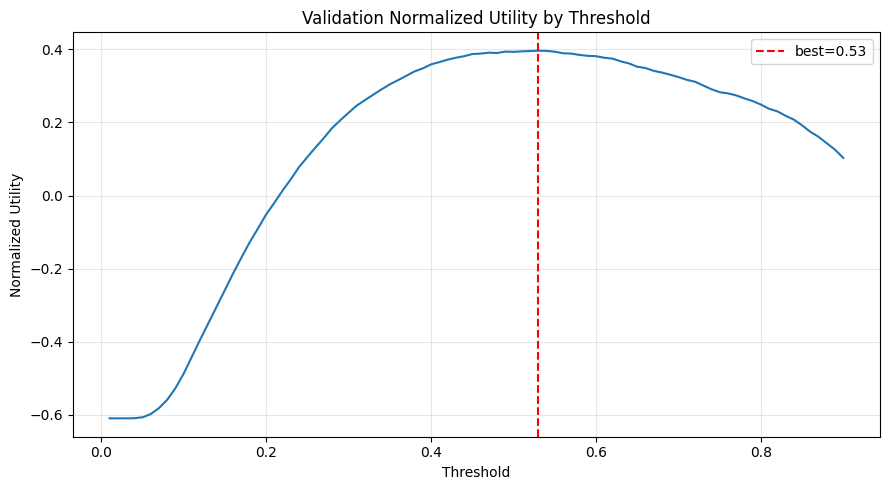

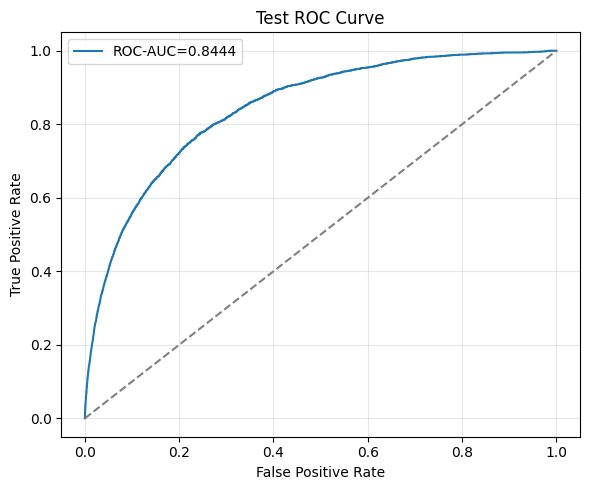

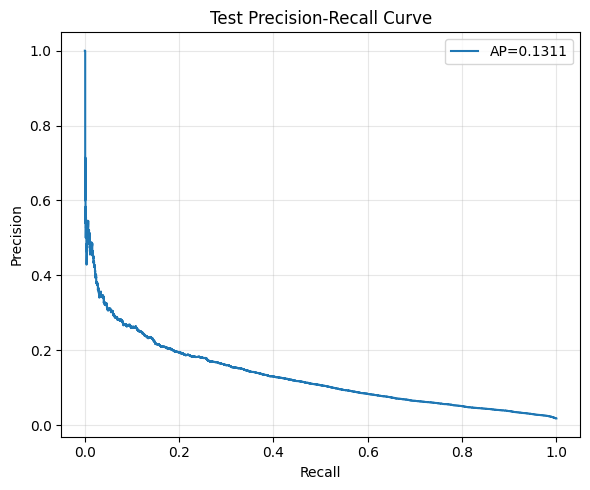

In [8]:
# %% [markdown]
# ## 9. Metrics va plots

# %%
def metric_report(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    out = {
        "roc_auc": float(roc_auc_score(y_true, probs)) if len(np.unique(y_true)) > 1 else None,
        "average_precision": float(average_precision_score(y_true, probs)) if len(np.unique(y_true)) > 1 else None,
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, preds).tolist(),
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred": float(np.mean(preds)),
    }
    return out


val_metrics = metric_report(y_val, val_probs_flat, best_threshold)
test_metrics = metric_report(y_test, test_probs_flat, best_threshold)
val_metrics["normalized_utility"] = best_val_utility
test_metrics["normalized_utility"] = test_utility

print("Validation metrics")
print(json.dumps(val_metrics, indent=2))
print("Test metrics")
print(json.dumps(test_metrics, indent=2))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, utilities)
plt.axvline(best_threshold, linestyle="--", color="red", label=f"best={best_threshold:.2f}")
plt.title("Validation Normalized Utility by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Normalized Utility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "utility_curve.png", dpi=140)
plt.show()

if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, test_probs_flat)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC={test_metrics['roc_auc']:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=140)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, test_probs_flat)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP={test_metrics['average_precision']:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pr_curve.png", dpi=140)
    plt.show()


In [9]:

# %% [markdown]
# ## 10. Export model, scaler, metadata
#
# File quan trong:
# - `model.json`: XGBoost model.
# - `scaler.json`: mean/std/log stats dung cho Spark preprocess.
# - `metadata.json`: threshold, feature order, metrics.
# - `sepsis_model_export.zip`: file zip de download tu Kaggle.

# %%
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUTPUT_DIR / "model.json"
model.save_model(model_path)

with (OUTPUT_DIR / "scaler.json").open("w", encoding="utf-8") as f:
    json.dump(scaler, f, indent=2)

metadata = {
    "model_name": MODEL_NAME,
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "xgboost_version": xgb.__version__,
    "feature_order": FEATURE_ORDER,
    "log_indices": sorted(LOG_INDICES),
    "window_size": WINDOW_SIZE,
    "base_feature_count": len(FEATURE_ORDER),
    "features_per_hour_after_engineering": len(FEATURE_ORDER) * 3,
    "model_feature_count": len(FEATURE_ORDER) * 3 * WINDOW_SIZE,
    "optimal_threshold": best_threshold,
    "best_iteration": int(model.best_iteration),
    "params": params,
    "train_patients": int(len(train_df)),
    "val_patients": int(len(val_df)),
    "test_patients": int(len(test_df)),
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

with (OUTPUT_DIR / "metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

split_info = {
    "train_ids": train_ids,
    "val_ids": val_ids,
    "test_ids": test_ids,
}
with (OUTPUT_DIR / "splits.json").open("w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=2)

readme_text = f"""
Sepsis model export
===================

Files:
- model.json: XGBoost model
- scaler.json: preprocessing statistics
- metadata.json: threshold, feature order, metrics
- splits.json: patient IDs used for train/val/test

Use in project:
1. Copy this folder to spark/app/models/kaggle_export/
2. Either upload model/scaler to MLflow, or modify Spark to load local model.json and scaler.json.
3. Make sure Spark preprocessing uses the same feature_order, log_indices, and window_size.

Optimal threshold: {best_threshold}
Test normalized utility: {test_utility}
"""
(OUTPUT_DIR / "README.txt").write_text(readme_text, encoding="utf-8")

if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()
with zipfile.ZipFile(OUTPUT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob("*"):
        zf.write(path, arcname=path.relative_to(OUTPUT_DIR.parent))

print("Exported:", OUTPUT_DIR)
print("Zip:", OUTPUT_ZIP)
print("Files:", [p.name for p in OUTPUT_DIR.iterdir()])




Exported: /kaggle/working/sepsis_model_export
Zip: /kaggle/working/sepsis_model_export.zip
Files: ['metadata.json', 'model.json', 'scaler.json', 'splits.json', 'README.txt']


In [ ]:


# %% [markdown]
# ## 11. Quick sanity check: load model tu file vua export

# %%
loaded = xgb.Booster()
loaded.load_model(str(model_path))
quick_probs = loaded.predict(dtest, iteration_range=(0, model.best_iteration + 1))
print("Loaded model probability sample:", quick_probs[:10])
print("Same prediction:", np.allclose(quick_probs[:100], test_probs_flat[:100]))




Loaded model probability sample: [0.28228435 0.35322762 0.35311237 0.36193594 0.36369166 0.3907283
 0.38659853 0.28349593 0.31034487 0.2600392 ]
Same prediction: True
